# Seasonal & Annual Precipitation Analysis
## LOCA2 Historical Ensemble — Joshua Tree (JOTR) & Mojave (MOJA)

This notebook produces three figures (2 columns × 3 rows):

| Row | Figure | Unit |
|-----|--------|------|
| 1 | Seasonal precipitation climatology | kg m⁻² s⁻¹ (raw stored unit) |
| 2 | Seasonal precipitation climatology | mm month⁻¹ (converted) |
| 3 | Mean annual precipitation map | mm year⁻¹ (converted) |

Thin lines = individual LOCA2 models; thick line = multi-model mean.

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import geopandas as gpd
from pathlib import Path

caladapt       = Path('../caladapt')
boundaries_dir = Path('../boundaries')

PARKS       = ['jotr', 'moja']
PARK_LABELS = {
    'jotr': 'Joshua Tree NP (JOTR)',
    'moja': 'Mojave NP (MOJA)',
}
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

# Field-site bounding box (WGS84; from field data)
BBOX_LON = (-116.0463, -116.0395)
BBOX_LAT = ( 33.90193,  33.90787)

# Load park boundary shapefiles
park_gdf = {
    park: gpd.read_file(boundaries_dir / f'{park}.shp')
    for park in PARKS
}

print('Setup complete.')
for park, gdf in park_gdf.items():
    print(f'  {park}: bounds = {gdf.total_bounds.round(4)}')

Setup complete.
  jotr: bounds = [-116.458    33.6702 -115.2622   34.1293]
  moja: bounds = [-116.165    34.7169 -114.9492   35.5908]


## Data overview

**Source**: Cal-Adapt LOCA2 downscaled ensemble, cropped to park boundaries
and saved as monthly NetCDF files.

**Variable**: `pr` — precipitation

**Stored unit** (from file metadata): `kg m⁻² s⁻¹`

**What the files actually contain**: the intake notebook computed monthly values via
`.resample(time='MS').sum()` applied to daily LOCA2 data.
Each daily `pr` value is a 24-hour average rate in kg m⁻² s⁻¹;
summing N daily values produces **the sum of daily rates over the month**.
The numeric values are therefore small (≈ 10⁻⁴), and the metadata unit label
`kg m⁻² s⁻¹` refers to the per-day rate that was summed — not a true monthly
accumulation yet. The unit conversion below corrects this.

## Seasonal climatology

A **seasonal climatology** collapses a multi-decadal time series into 12 monthly
long-term averages by grouping all January values, all February values, etc.,
and computing the mean within each group.

Here we first compute the **spatial mean** across each park's grid cells
(area-average of the cropped domain), then derive the 12-month climatology.
This produces one curve per model.

In [2]:
def load_seasonal_climatology(park):
    # For each model: load historical monthly pr, compute spatial mean,
    # then group by month and average across years -> shape (12,)
    # Returns dict: {model_name: np.ndarray(12,)} in raw kg m-2 s-1
    files = sorted(caladapt.glob(f'*_loca2_historical_pr_{park}_monthly.nc'))
    clims = {}
    for f in files:
        model = f.stem.split('_loca2')[0]   # e.g. 'access-cm2_r1i1p1f1'
        with xr.open_dataset(f) as ds:
            da = ds['pr']
            if 'member_id' in da.dims:
                da = da.squeeze('member_id', drop=True)
            da_sm = da.mean(dim=['lat', 'lon'])                  # spatial mean
            clim  = da_sm.groupby('time.month').mean('time')    # 12-month clim
            clims[model] = clim.values
    print(f'  {park}: {len(clims)} models loaded')
    return clims


print('Loading seasonal climatologies ...')
clims = {park: load_seasonal_climatology(park) for park in PARKS}

# Report stored units from file metadata
sample_f = sorted(caladapt.glob('*_loca2_historical_pr_jotr_monthly.nc'))[0]
with xr.open_dataset(sample_f) as ds:
    RAW_UNITS = ds['pr'].attrs.get('units', 'unknown')
print(f'\nUnits in file metadata : {RAW_UNITS}')
print(f'Number of models       : {len(clims["jotr"])}')

Loading seasonal climatologies ...
  jotr: 15 models loaded
  moja: 15 models loaded

Units in file metadata : kg m-2 s-1
Number of models       : 15


### Figure 1 — Seasonal climatology in raw stored units (`kg m⁻² s⁻¹`)

Values are small because they are **sums of daily precipitation rates**;
the unit conversion is explained in the next section.

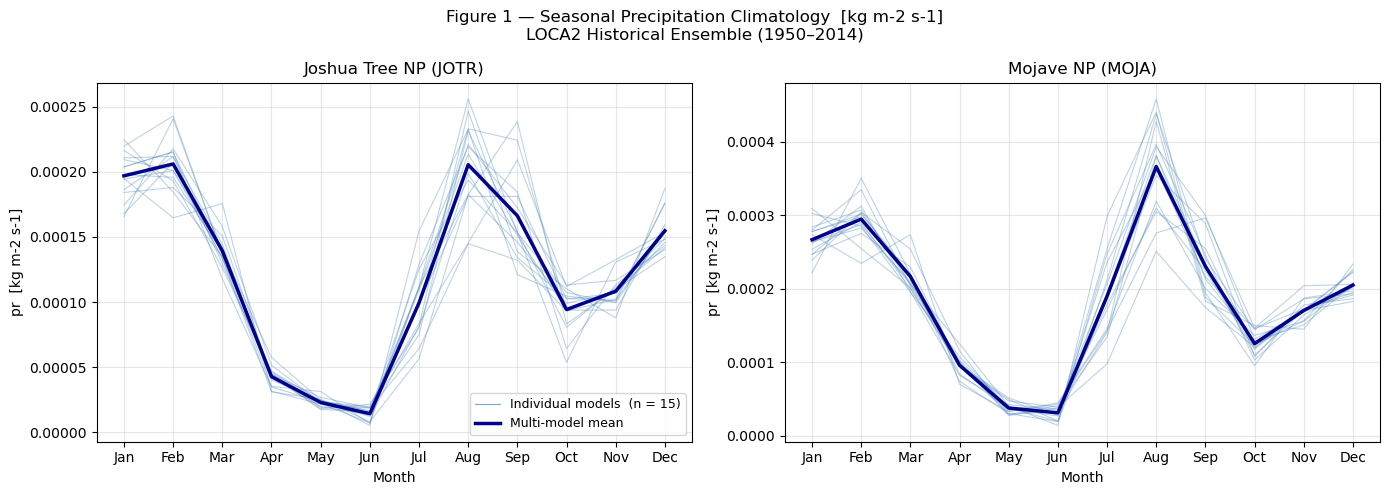

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, park in zip(axes, PARKS):
    models_data = clims[park]
    all_clims   = np.array(list(models_data.values()))  # (n_models, 12)

    # Thin lines: individual models
    for clim in models_data.values():
        ax.plot(range(1, 13), clim,
                color='steelblue', alpha=0.35, linewidth=0.8)

    # Thick line: multi-model mean
    mmm = all_clims.mean(axis=0)
    ax.plot(range(1, 13), mmm,
            color='darkblue', linewidth=2.5)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTHS)
    ax.set_xlabel('Month')
    ax.set_ylabel(f'pr  [{RAW_UNITS}]')
    ax.set_title(PARK_LABELS[park])
    ax.grid(True, alpha=0.3)

thin_h  = mlines.Line2D([], [], color='steelblue', alpha=0.7, linewidth=0.8,
                        label=f'Individual models  (n = {len(clims["jotr"])})')
thick_h = mlines.Line2D([], [], color='darkblue', linewidth=2.5,
                        label='Multi-model mean')
axes[0].legend(handles=[thin_h, thick_h], fontsize=9)

fig.suptitle(
    f'Figure 1 \u2014 Seasonal Precipitation Climatology  [{RAW_UNITS}]\n'
    'LOCA2 Historical Ensemble (1950\u20132014)',
    fontsize=12)
plt.tight_layout()
plt.show()

## Unit conversion: `kg m⁻² s⁻¹` → `mm month⁻¹`

### Step 1 — Water-depth equivalence

Liquid water density: ρ = 1000 kg m⁻³

A mass flux of 1 kg m⁻² corresponds to a water column of

$$\Delta z = \frac{m}{\rho} = \frac{1\;\text{kg m}^{-2}}{1000\;\text{kg m}^{-3}} = 10^{-3}\;\text{m} = 1\;\text{mm}$$

Therefore: **1 kg m⁻² ≡ 1 mm** of precipitation depth.

### Step 2 — Rate → daily accumulation

Each daily LOCA2 value is a 24-hour average rate $r$ [kg m⁻² s⁻¹].  
Multiplying by the number of seconds in a day gives the **daily accumulation**:

$$\text{daily accumulation} = r \times 86\,400\;\text{s day}^{-1} \quad [\text{mm day}^{-1}]$$

### Step 3 — What the monthly files store

The intake notebook ran `.resample(time='MS').sum()` on the daily data.  
For a month with *N* days this stores:

$$\text{stored monthly value} = \sum_{i=1}^{N} r_i \quad [\text{kg m}^{-2}\text{ s}^{-1}]$$

### Step 4 — Conversion to mm month⁻¹

$$\text{monthly total [mm]} = 86\,400 \times \sum_{i=1}^{N} r_i
= \sum_{i=1}^{N} \underbrace{r_i \times 86\,400}_{\text{mm day}^{-1}}$$

The factor 86 400 commutes through the sum, so:

$$\boxed{\text{pr [mm month}^{-1}] = \text{stored value} \times 86\,400}$$

**Note**: the conversion factor is the same regardless of month length because
the sum already counts the actual number of days in each month (N = 28–31).

### Figure 2 — Seasonal climatology in `mm month⁻¹`

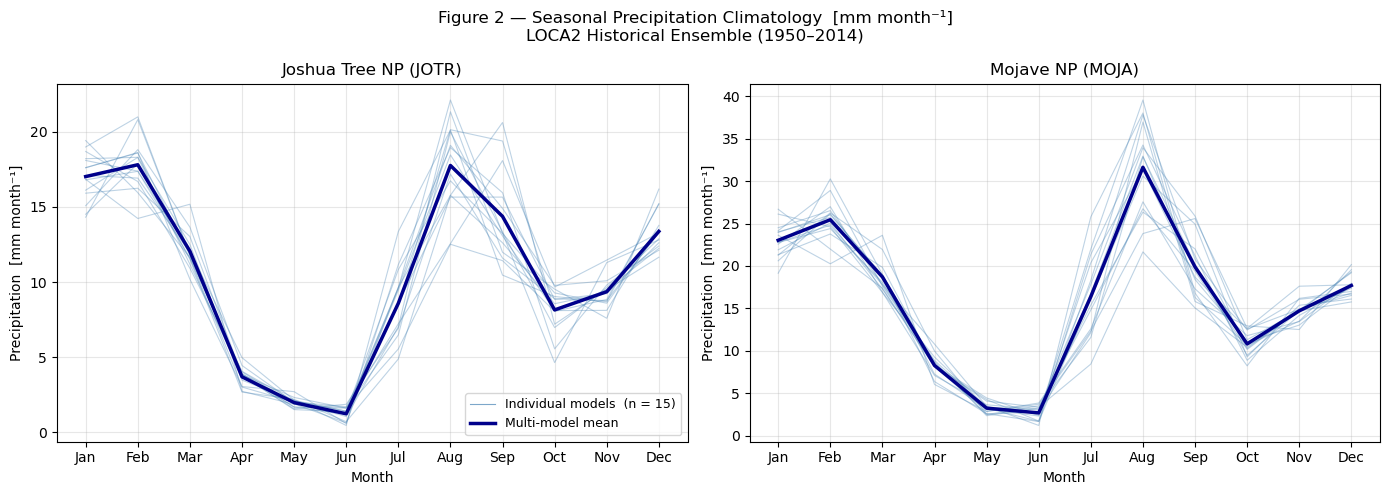

In [4]:
CONV      = 86_400        # seconds per day
CONV_UNIT = 'mm month\u207b\u00b9'  # mm month⁻¹

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, park in zip(axes, PARKS):
    models_data = clims[park]
    all_clims   = np.array(list(models_data.values()))  # (n_models, 12)

    # Thin lines: individual models (converted)
    for clim in models_data.values():
        ax.plot(range(1, 13), clim * CONV,
                color='steelblue', alpha=0.35, linewidth=0.8)

    # Thick line: multi-model mean (converted)
    mmm = (all_clims * CONV).mean(axis=0)
    ax.plot(range(1, 13), mmm,
            color='darkblue', linewidth=2.5)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTHS)
    ax.set_xlabel('Month')
    ax.set_ylabel(f'Precipitation  [{CONV_UNIT}]')
    ax.set_title(PARK_LABELS[park])
    ax.grid(True, alpha=0.3)

thin_h  = mlines.Line2D([], [], color='steelblue', alpha=0.7, linewidth=0.8,
                        label=f'Individual models  (n = {len(clims["jotr"])})')
thick_h = mlines.Line2D([], [], color='darkblue', linewidth=2.5,
                        label='Multi-model mean')
axes[0].legend(handles=[thin_h, thick_h], fontsize=9)

fig.suptitle(
    f'Figure 2 \u2014 Seasonal Precipitation Climatology  [{CONV_UNIT}]\n'
    'LOCA2 Historical Ensemble (1950\u20132014)',
    fontsize=12)
plt.tight_layout()
plt.show()

## Mean annual precipitation map

### Aggregation steps

Starting from the monthly files (stored in kg m⁻² s⁻¹):

1. **Unit conversion** (same factor as above):  
   `pr_mm = pr_stored × 86 400`  → units: mm month⁻¹

2. **Annual total per model per year** — sum the 12 monthly values:  
   `pr_annual = pr_mm.resample(time='YS').sum()`  → units: mm year⁻¹  
   Each grid cell accumulates one value per calendar year.

3. **Historical mean** — average over all years (1950–2014):  
   `pr_mean = pr_annual.mean('time')`  → units: mm year⁻¹  
   This produces one 2-D spatial field (lat × lon) per model.

4. **Multi-model mean** — stack all models and average:  
   `pr_mmm = xr.concat(model_fields, dim='model').mean('model')`

### Color scale

Both park panels share the same `vmin` / `vmax`, derived from the 2nd–98th
percentile of the combined multi-model mean values across both parks.
This ensures a fair visual comparison of the two areas.

### Bounding box

The red rectangle marks the field-site extent:  
longitude [−116.0463, −116.0395], latitude [33.902, 33.908]  
(≈ 600 m × 700 m). This site lies inside JOTR; it is below the latitudinal
range of MOJA (34.72°N+), so the box will only be visible on the JOTR panel.

Computing mean annual precipitation maps ...
Shared color scale: 0.0 – 274.7 mm year⁻¹


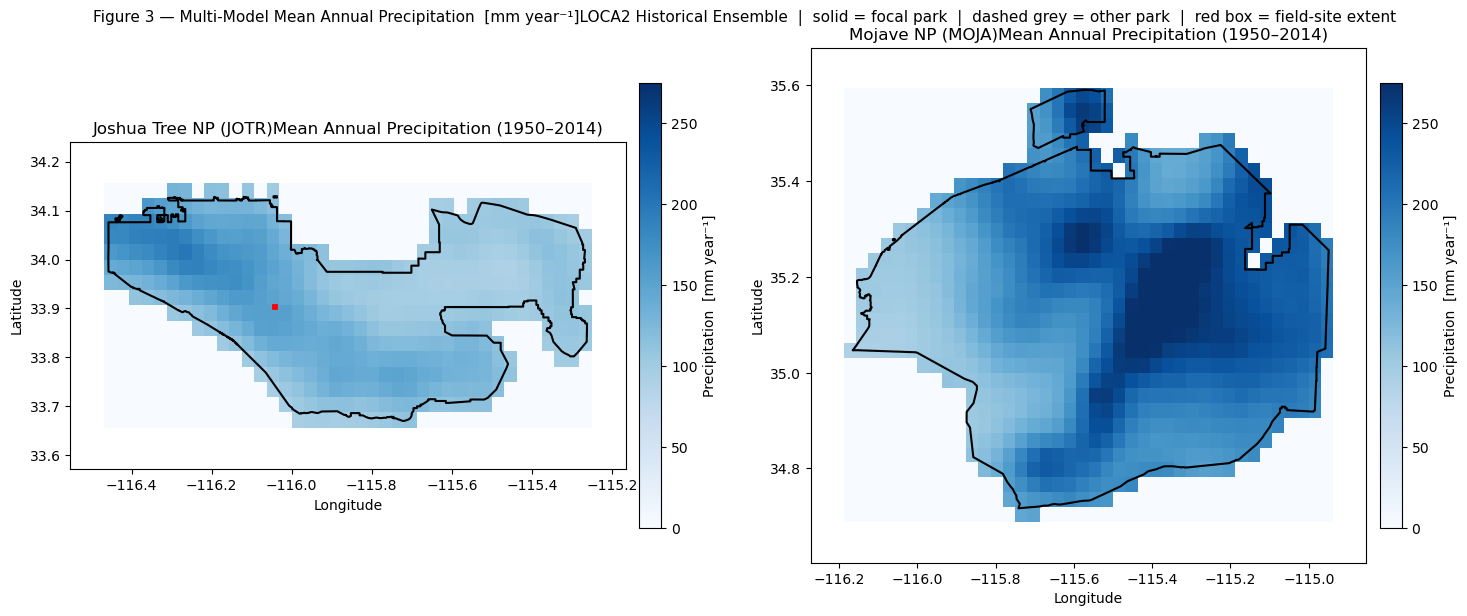

In [ ]:
def load_annual_mean_map(park, conv=86_400):
    # Steps:
    # 1. Convert stored kg m-2 s-1 to mm month-1  (*= conv)
    # 2. Annual total: resample by year, sum months  (mm year-1)
    # 3. Historical mean: average over all years
    # Returns multi-model mean DataArray (lat x lon)
    files = sorted(caladapt.glob(f'*_loca2_historical_pr_{park}_monthly.nc'))
    maps = []
    for f in files:
        with xr.open_dataset(f) as ds:
            da = ds['pr']
            if 'member_id' in da.dims:
                da = da.squeeze('member_id', drop=True)
            da_mm     = da * conv
            da_annual = da_mm.resample(time='YS').sum('time')
            da_mean   = da_annual.mean('time')
            maps.append(da_mean.load())
    stacked = xr.concat(maps, dim='model')
    return stacked.mean('model')


print('Computing mean annual precipitation maps ...')
mmm_maps = {park: load_annual_mean_map(park) for park in PARKS}

# Shared color scale: 2nd-98th percentile across both parks
all_vals = np.concatenate([mmm_maps[p].values.ravel() for p in PARKS])
all_vals = all_vals[~np.isnan(all_vals)]
vmin = float(np.nanpercentile(all_vals, 2))
vmax = float(np.nanpercentile(all_vals, 98))
print(f'Shared color scale: {vmin:.1f} – {vmax:.1f} mm year⁻¹')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, park in zip(axes, PARKS):
    da = mmm_maps[park]

    im = ax.pcolormesh(
        da.lon, da.lat, da.values,
        cmap='Blues', vmin=vmin, vmax=vmax,
    )

    # Both park boundaries: focal park solid black, other park dashed grey
    for other_park in PARKS:
        is_focal = (other_park == park)
        park_gdf[other_park].plot(
            ax=ax,
            facecolor='none',
            edgecolor='black' if is_focal else '#888888',
            linewidth=1.5 if is_focal else 0.8,
            linestyle='-' if is_focal else '--',
        )

    # Field-site bounding box (red rectangle)
    rect = mpatches.Rectangle(
        xy=(BBOX_LON[0], BBOX_LAT[0]),
        width =BBOX_LON[1] - BBOX_LON[0],
        height=BBOX_LAT[1] - BBOX_LAT[0],
        linewidth=2, edgecolor='red', facecolor='none', zorder=5,
    )
    ax.add_patch(rect)

    # Zoom to the focal park's data extent
    ax.set_xlim(float(da.lon.min()) - 0.1, float(da.lon.max()) + 0.1)
    ax.set_ylim(float(da.lat.min()) - 0.1, float(da.lat.max()) + 0.1)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)
    cb.set_label('Precipitation  [mm year⁻¹]')
    ax.set_title(
        f'{PARK_LABELS[park]}Mean Annual Precipitation (1950–2014)')

fig.suptitle(
    'Figure 3 — Multi-Model Mean Annual Precipitation  '
    '[mm year⁻¹]'
    'LOCA2 Historical Ensemble  |  solid = focal park  |  '
    'dashed grey = other park  |  red box = field-site extent',
    fontsize=11)
plt.tight_layout()
plt.show()
